# <center> Семинар RL для рекомендательных систем</center>

## Цель семинара

В этом семинаре мы строим полный пайплайн **sequence recommendation + reward modeling + RL fine-tuning** на датасете KION:

1. обучаем базовую модель **multi-step next-item prediction** по пользовательским последовательностям;
2. обучаем **reward model**, которая предсказывает полезность кандидата:
   - в первую очередь `time_to_next_event`,
   - опционально `watch_duration`;
3. дообучаем policy через **GRPO** так, чтобы она генерировала **не один item, а slate из `X` items** с максимальной суммарной наградой;
4. анализируем, **что именно выучила RL-модель** и как поменялось её поведение.

---

## Идея семинара

Супервизорный этап учит модель продолжать историческую последовательность пользователя.  
RL-этап с reward model позволяет **сместить политику в сторону метрики, которая нам действительно важна**: например, более короткого времени до следующего возвращения пользователя.

Важная оговорка: reward model здесь **оффлайн** и обучается на исторических данных. Поэтому мы оптимизируем не истинную онлайн-метрику, а её прокси.

---

## Что меняется по сравнению с обычным next-item

Вместо постановки "`history -> один следующий item`" мы используем:

- `history -> item_1 item_2 ... item_X`

То есть policy должна сгенерировать **короткий slate**.  
А reward для GRPO считается как **агрегированная полезность всего slate**, а не одного действия.

Это ближе к реальной задаче рекомендаций, где мы часто показываем пользователю не один объект, а **несколько кандидатов сразу**.

## План работы

- загрузим и подготовим последовательности KION;
- переведём item recommendation в **language modeling** постановку;
- обучим маленький autoregressive transformer (GPT-2 style);
- обучим reward model на тех же историях;
- запустим **GRPO** из `trl` с минимальным кастомным кодом;
- сравним supervised policy и RL policy;
- попробуем интерпретировать сдвиг в рекомендациях.

In [ ]:

# Если работаешь в Colab / чистом окружении, раскомментируй:
# !pip install -q transformers datasets accelerate trl peft sentencepiece scikit-learn matplotlib pandas numpy

In [34]:
import os
import json
import math
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import Dataset as HFDataset

from transformers import (
    GPT2Config,
    GPT2LMHeadModel,
    GPT2Model,
    Trainer,
    TrainingArguments,
    PreTrainedTokenizerFast,
    set_seed,
)

from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace

from trl import GRPOConfig, GRPOTrainer

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 1. Загрузка данных KION

Ниже сделан устойчивый загрузчик, потому что в разных версиях семинаров и выгрузок названия файлов и колонок могут немного отличаться.

По умолчанию ноутбук ищет:
- `interactions.csv`
- `items.csv`
- `users.csv`

сначала в текущей папке, потом на уровень выше, потом на два уровня выше.

In [35]:

def find_file(candidates: List[str]) -> Optional[str]:
    search_roots = [
        Path("."),
        Path(".."),
        Path("../.."),
        Path("/mnt/data"),
    ]
    for root in search_roots:
        for name in candidates:
            p = root / name
            if p.exists():
                return str(p)
    return None

interactions_path = find_file(["interactions.csv", "kion_interactions.csv"])
items_path = find_file(["items.csv", "kion_items.csv"])
users_path = find_file(["users.csv", "kion_users.csv"])

print("interactions_path =", interactions_path)
print("items_path        =", items_path)
print("users_path        =", users_path)

interactions_path = ../../interactions.csv
items_path        = ../../items.csv
users_path        = ../../users.csv


In [36]:

if interactions_path is None:
    raise FileNotFoundError(
        "Не найден interactions.csv. Положи файл рядом с ноутбуком "
        "или в ../, ../../, /mnt/data."
    )

interactions = pd.read_csv(interactions_path)
items = pd.read_csv(items_path) if items_path is not None else pd.DataFrame()
users = pd.read_csv(users_path) if users_path is not None else pd.DataFrame()

print("Interactions:", interactions.shape)
print("Items       :", items.shape)
print("Users       :", users.shape)

Interactions: (5476251, 5)
Items       : (15963, 14)
Users       : (840197, 5)


In [37]:

interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


## 2. Нормализация колонок

Нам нужны как минимум:
- идентификатор пользователя,
- идентификатор айтема,
- время взаимодействия.

Опционально:
- watch duration / total duration;
- дата следующего события.

Поскольку в выгрузках названия могут отличаться, используем авто-детект.

In [38]:

def detect_column(df: pd.DataFrame, candidates: List[str], required: bool = True) -> Optional[str]:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    if required:
        raise ValueError(f"Не удалось найти колонку из кандидатов: {candidates}")
    return None

USER_COL = detect_column(interactions, ["user_id", "uid", "profile_id"])
ITEM_COL = detect_column(interactions, ["item_id", "asset_id", "movie_id", "content_id"])
TIME_COL = detect_column(interactions, ["last_watch_dt", "event_time", "timestamp", "datetime", "watch_dt"])

WATCH_COL = detect_column(
    interactions,
    ["watch_duration", "watched_pct", "total_dur", "watchtime", "duration", "watched_time"],
    required=False,
)

print("USER_COL =", USER_COL)
print("ITEM_COL =", ITEM_COL)
print("TIME_COL =", TIME_COL)
print("WATCH_COL =", WATCH_COL)

USER_COL = user_id
ITEM_COL = item_id
TIME_COL = last_watch_dt
WATCH_COL = watched_pct


In [39]:

df = interactions.copy()

df = df[[c for c in [USER_COL, ITEM_COL, TIME_COL, WATCH_COL] if c is not None]].copy()
df = df.rename(columns={
    USER_COL: "user_id",
    ITEM_COL: "item_id",
    TIME_COL: "event_time",
    **({WATCH_COL: "watch_value"} if WATCH_COL is not None else {})
})

df["event_time"] = pd.to_datetime(df["event_time"])
df = df.sort_values(["user_id", "event_time"]).reset_index(drop=True)

if "watch_value" not in df.columns:
    df["watch_value"] = np.nan

df.head()

,user_id,item_id,event_time,watch_value
0,0,12192,2021-07-16,0.0
1,0,7102,2021-07-19,3.0
2,0,14359,2021-07-19,2.0
3,0,15297,2021-07-19,0.0
4,0,9728,2021-07-19,0.0


## 3. Небольшой sampling для ускорения

Для семинарского запуска лучше ограничить размер данных, чтобы всё реально обучалось на одной GPU или даже CPU.

In [40]:

MAX_USERS = 50000      # можно увеличить при наличии ресурсов
MIN_SEQ_LEN = 5
MAX_SEQ_LEN = 50      # длина контекста, который подаём модели

rng = np.random.default_rng(42)
all_users = df["user_id"].drop_duplicates().values

if len(all_users) > MAX_USERS:
    sampled_users = rng.choice(all_users, size=MAX_USERS, replace=False)
    df = df[df["user_id"].isin(sampled_users)].copy()

user_lengths = df.groupby("user_id").size()
good_users = user_lengths[user_lengths >= MIN_SEQ_LEN].index
df = df[df["user_id"].isin(good_users)].copy()

print("Interactions:", len(df))
print("Users       :", df['user_id'].nunique())
print("Items       :", df['item_id'].nunique())
print("Avg seq len :", df.groupby('user_id').size().mean())

Interactions: 223709
Users       : 15665
Items       : 8118
Avg seq len : 14.280817108203001


## 4. Строим целевые reward-таргеты

Сделаем две возможные награды:

1. **`watch_value`** — если в датасете есть длительность просмотра;
2. **`time_to_next_event_hours`** — сколько часов до следующего взаимодействия пользователя.

Для RL обычно удобнее, когда *больше = лучше*.  
Поэтому для `time_to_next_event` используем преобразование:

\[
reward = - \log(1 + \Delta t_{hours})
\]

То есть более быстрый возврат пользователя даёт **большую** награду.

In [41]:
df = df.sort_values(by=["user_id", "event_time"], ascending=True)
df["next_event_time"] = df.groupby("user_id")["event_time"].shift(-1)
df["time_to_next_event_hours"] = (
    (df["next_event_time"] - df["event_time"]).dt.total_seconds() / 3600.0
)

# Безопасные преобразования
if "watch_value" in df.columns:
    df["watch_value"] = pd.to_numeric(df["watch_value"], errors="coerce")

df["reward_return_quick"] = -np.log1p(df["time_to_next_event_hours"].clip(lower=0))

# Вариант нормализованной награды по watch duration
if "watch_value" in df.columns and df["watch_value"].notna().sum() > 0:
    q99 = np.nanquantile(df["watch_value"], 0.99)
    denom = max(q99, 1e-6)
    df["reward_watch"] = np.clip(df["watch_value"] / denom, 0.0, 1.0)
else:
    df["reward_watch"] = np.nan

df["is_last_event_in_sequence"] = df["next_event_time"].isna().astype(int)

# reward: штраф или награда за то, что событие последнее
# вариант 1: просто бинарная награда
df["reward_is_last_event"] = 1-df["is_last_event_in_sequence"].astype(float)

df[["user_id", "item_id", "event_time", "time_to_next_event_hours", "reward_return_quick", "reward_watch",'reward_is_last_event']].head(10)

,user_id,item_id,event_time,time_to_next_event_hours,reward_return_quick,reward_watch,reward_is_last_event
0,0,12192,2021-07-16,72.0,-4.290459,0.00,1.0
1,0,7102,2021-07-19,0.0,-0.000000,0.03,1.0
2,0,14359,2021-07-19,0.0,-0.000000,0.02,1.0
3,0,15297,2021-07-19,0.0,-0.000000,0.00,1.0
4,0,9728,2021-07-19,24.0,-3.218876,0.00,1.0
5,0,6006,2021-07-20,NaN,NaN,0.00,0.0
8,2,7571,2021-05-20,24.0,-3.218876,1.00,1.0
9,2,11577,2021-05-21,0.0,-0.000000,0.98,1.0
10,2,16166,2021-05-21,192.0,-5.262690,0.95,1.0
11,2,8936,2021-05-29,0.0,-0.000000,0.01,1.0


## 5. Разбиение на train / valid / test по пользователям

Делаем сплит по пользователям, чтобы оценка была ближе к реальному cold-ish split по субъектам.

In [42]:

user_ids = df["user_id"].drop_duplicates().values
train_users, temp_users = train_test_split(user_ids, test_size=0.2, random_state=42)
valid_users, test_users = train_test_split(temp_users, test_size=0.5, random_state=42)

train_df = df[df["user_id"].isin(train_users)].copy()
valid_df = df[df["user_id"].isin(valid_users)].copy()
test_df = df[df["user_id"].isin(test_users)].copy()

print("Train users:", len(train_users), "interactions:", len(train_df))
print("Valid users:", len(valid_users), "interactions:", len(valid_df))
print("Test users :", len(test_users), "interactions:", len(test_df))

Train users: 12532 interactions: 180687
Valid users: 1566 interactions: 21975
Test users : 1567 interactions: 21047


## 6. Построение словаря айтемов и токенизации

Мы сведём recommendation к sequence modeling:

история пользователя:
`item_17 item_42 item_91`

модель учится продолжать последовательность:
`item_123 item_88 item_7`

Чтобы и supervised, и RL-часть хорошо работали с `trl`, сразу используем
**обычный HuggingFace tokenizer** (`PreTrainedTokenizerFast`) поверх словаря:
- `<pad>`
- `<bos>`
- `<eos>`
- `<unk>`
- `item_{id}`

In [43]:
SLATE_SIZE = 3
MAX_SEQ_LEN = 50

special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]
item_tokens = [f"item_{x}" for x in sorted(train_df["item_id"].astype(str).unique())]

vocab = special_tokens + item_tokens
token2id = {tok: i for i, tok in enumerate(vocab)}
id2token = {i: tok for tok, i in token2id.items()}

PAD_ID = token2id["<pad>"]
BOS_ID = token2id["<bos>"]
EOS_ID = token2id["<eos>"]
UNK_ID = token2id["<unk>"]

def item_to_token(item):
    tok = f"item_{item}"
    return tok if tok in token2id else "<unk>"

def encode_items(items: List[str]) -> List[int]:
    return [token2id.get(item_to_token(x), UNK_ID) for x in items]

base_tokenizer = Tokenizer(WordLevel(vocab=token2id, unk_token="<unk>"))
base_tokenizer.pre_tokenizer = Whitespace()

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=base_tokenizer,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>",
)

print("Vocab size:", len(vocab))
print("Tokenizer class:", type(tokenizer))

Vocab size: 7736
Tokenizer class: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>


## 7. Готовим supervised датасет для multi-step next-item prediction

Для каждого пользователя строим пары:

- `prompt = префикс последовательности`
- `target_items = следующие X айтемов`

Пример при `SLATE_SIZE = 3`:
- история: `[i1, i2, i3, i4, i5, i6]`
- обучающие пары:
  - `[i1] -> [i2, i3, i4]`
  - `[i1, i2] -> [i3, i4, i5]`
  - `[i1, i2, i3] -> [i4, i5, i6]`

На supervised-этапе модель учится продолжать последовательность сразу на несколько шагов вперёд.

In [44]:
def build_prefix_examples(frame: pd.DataFrame, max_seq_len: int = 50, slate_size: int = 1):
    
    examples = []
    for user_id, g in frame.groupby("user_id"):
        items_seq = g["item_id"].astype(str).tolist()
        times_seq = g["event_time"].tolist()
        rw_return = g["reward_return_quick"].tolist()
        rw_watch = g["reward_watch"].tolist()
        rw_last = g["reward_is_last_event"].tolist()


        for t in range(1, len(items_seq)):
            if t + slate_size > len(items_seq):
                break

            prefix_items = items_seq[max(0, t - max_seq_len):t]
            target_items = items_seq[t:t + slate_size]
            target_item = target_items[0]

            reward_return_target = rw_return[t - 1] if t - 1 < len(rw_return) else np.nan
            reward_watch_target = rw_watch[t] if t < len(rw_watch) else np.nan
            reward_is_last_event = rw_last[t] if t < len(rw_last) else np.nan

            examples.append({
                "user_id": user_id,
                "prefix_items": prefix_items,
                "target_item": target_item,
                "target_items": target_items,
                "target_time": times_seq[t],
                "reward_return_quick": reward_return_target,
                "reward_watch": reward_watch_target,
                "reward_is_last_event": reward_is_last_event
            })
    return pd.DataFrame(examples)

SLATE_SIZE = 1

train_examples = build_prefix_examples(train_df, MAX_SEQ_LEN, SLATE_SIZE)
valid_examples = build_prefix_examples(valid_df, MAX_SEQ_LEN, SLATE_SIZE)
test_examples = build_prefix_examples(test_df, MAX_SEQ_LEN, SLATE_SIZE)

print(train_examples.shape, valid_examples.shape, test_examples.shape)
train_examples.head()

(168155, 8) (20409, 8) (19480, 8)


,user_id,prefix_items,target_item,target_items,target_time,reward_return_quick,reward_watch,reward_is_last_event
0,2,[7571],11577,[11577],2021-05-21,-3.218876,0.98,1.0
1,2,"[7571, 11577]",16166,[16166],2021-05-21,-0.000000,0.95,1.0
2,2,"[7571, 11577, 16166]",8936,[8936],2021-05-29,-5.262690,0.01,1.0
3,2,"[7571, 11577, 16166, 8936]",4436,[4436],2021-05-29,-0.000000,0.30,1.0
4,2,"[7571, 11577, 16166, 8936, 4436]",4475,[4475],2021-05-30,-3.218876,1.00,1.0


In [45]:
def build_lm_example(prefix_items: List[str], target_items: List[str]):
    prefix_ids = encode_items(prefix_items[-MAX_SEQ_LEN:])
    target_ids = encode_items(target_items[:SLATE_SIZE])

    input_ids = [BOS_ID] + prefix_ids + target_ids + [EOS_ID]
    labels = [-100] * (1 + len(prefix_ids)) + target_ids + [EOS_ID]
    attention_mask = [1] * len(input_ids)
    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask,
    }

train_lm = [build_lm_example(r.prefix_items, r.target_items) for r in train_examples.itertuples()]
valid_lm = [build_lm_example(r.prefix_items, r.target_items) for r in valid_examples.itertuples()]

In [46]:

class LMDataset(Dataset):
    def __init__(self, examples, pad_id=0):
        self.examples = examples
        self.pad_id = pad_id

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

def lm_collator(batch):
    max_len = max(len(x["input_ids"]) for x in batch)
    out = {"input_ids": [], "labels": [], "attention_mask": []}
    for x in batch:
        pad = max_len - len(x["input_ids"])
        out["input_ids"].append(x["input_ids"] + [PAD_ID] * pad)
        out["labels"].append(x["labels"] + [-100] * pad)
        out["attention_mask"].append(x["attention_mask"] + [0] * pad)
    return {k: torch.tensor(v, dtype=torch.long) for k, v in out.items()}

train_lm_ds = LMDataset(train_lm)
valid_lm_ds = LMDataset(valid_lm)

## 8. Базовая policy: GPT-2 style модель

Делаем небольшой GPT-2 style LM прямо на нашем словаре айтемов.

Важно, что теперь policy обучается генерировать **короткое продолжение длины `SLATE_SIZE`**, а не только один следующий item.

In [47]:
gpt2_cfg = GPT2Config(
    vocab_size=len(vocab),
    n_positions=MAX_SEQ_LEN + SLATE_SIZE + 4,
    n_ctx=MAX_SEQ_LEN + SLATE_SIZE + 4,
    n_embd=128,
    n_layer=4,
    n_head=4,
    bos_token_id=BOS_ID,
    eos_token_id=EOS_ID,
    pad_token_id=PAD_ID,
)

policy_model = GPT2LMHeadModel(gpt2_cfg)
policy_model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(7736, 128)
    (wpe): Embedding(55, 128)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPT2Block(
        (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=384, nx=128)
          (c_proj): Conv1D(nf=128, nx=128)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=512, nx=128)
          (c_proj): Conv1D(nf=128, nx=512)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=128, out_features=7736, bias=False)
)

In [48]:

training_args = TrainingArguments(
    output_dir="./outputs_rl_seminar/base_policy",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,
    num_train_epochs=3,
    logging_steps=50,
    eval_strategy="steps",
    save_strategy="steps",
    report_to="none",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=policy_model,
    args=training_args,
    train_dataset=train_lm_ds,
    eval_dataset=valid_lm_ds,
    data_collator=lm_collator,
)

trainer.train()
print("Раскомментируй trainer.train() для запуска обучения")

Step,Training Loss,Validation Loss
50,7.011724,5.897448
100,5.169352,4.573202
150,4.529641,4.482893
200,4.522521,4.435038
250,4.395466,4.403231
300,4.447824,4.392526
350,4.394211,4.359223
400,4.340882,4.357809
450,4.375890,4.337953
500,4.342926,4.329935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9. Генерация slate из нескольких айтемов

Теперь нам нужна функция, которая по истории генерирует не один item, а **короткий slate**:

`history -> item_a item_b item_c`

Во время генерации:
- запрещаем специальные токены;
- можем штрафовать повторы внутри slate;
- используем sampling, чтобы GRPO видел пространство действий, а не только greedy-декодирование.

In [49]:
def decode_item_token(tok_id: int) -> Optional[str]:
    token = id2token.get(int(tok_id), "<unk>")
    return token.replace("item_", "") if token.startswith("item_") else None

def generate_item_slate(
    model: GPT2LMHeadModel,
    prefix_items: List[str],
    slate_size: int = 3,
    top_k: int = 20,
    temperature: float = 1.0,
    forbid_history_repeats: bool = False,
):
    model.eval()
    generated_item_ids = []
    generated_items = []

    input_ids = [BOS_ID] + encode_items(prefix_items[-MAX_SEQ_LEN:])
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        for _ in range(slate_size):
            outputs = model(input_ids=input_ids)
            logits = outputs.logits[0, -1] / max(temperature, 1e-6)

            banned = {PAD_ID, BOS_ID, EOS_ID}
            for bid in banned:
                logits[bid] = -1e9

            for gid in generated_item_ids:
                logits[gid] = -1e9

            if forbid_history_repeats:
                for hist_id in encode_items(prefix_items[-MAX_SEQ_LEN:]):
                    logits[hist_id] = -1e9

            if top_k is not None and top_k < logits.shape[0]:
                _, top_idx = torch.topk(logits, k=top_k)
                mask = torch.full_like(logits, -1e9)
                mask[top_idx] = logits[top_idx]
                logits = mask

            probs = torch.softmax(logits, dim=-1)
            sampled_id = torch.multinomial(probs, num_samples=1).item()

            generated_item_ids.append(sampled_id)
            item = decode_item_token(sampled_id)
            if item is not None:
                generated_items.append(item)

            next_token = torch.tensor([[sampled_id]], dtype=torch.long).to(model.device)
            input_ids = torch.cat([input_ids, next_token], dim=1)

    return generated_items, generated_item_ids

## 10. Быстрая оценка supervised policy

Для multi-item генерации удобно смотреть:
- `HitRate@1` — совпал ли первый предсказанный item с первым истинным;
- `Recall@X` — сколько из истинных следующих `X` айтемов попало в сгенерированный slate;
- `Predicted slate reward` — суммарная награда по reward model на всём slate.

In [50]:
def evaluate_slate_metrics(model, examples_df, n_eval: int = 1000, slate_size: int = 3):
    rows = examples_df.head(n_eval)
    hr1, recall_x = [], []
    debug_rows = []

    for r in tqdm(list(rows.itertuples()), total=len(rows)):
        pred_items, _ = generate_item_slate(
            model, r.prefix_items, slate_size=slate_size, top_k=20, temperature=1.0
        )

        true_items = list(map(str, r.target_items))
        pred_set = set(map(str, pred_items))
        true_set = set(true_items)

        hr1.append(int(len(pred_items) > 0 and str(pred_items[0]) == str(true_items[0])))
        recall_x.append(len(pred_set & true_set) / max(len(true_set), 1))

        if len(debug_rows) < 10:
            debug_rows.append({
                "prefix": r.prefix_items[-10:],
                "pred_items": pred_items,
                "true_items": true_items,
            })

    debug_df = pd.DataFrame(debug_rows)
    return {
        f"HitRate@{slate_size}": float(np.mean(hr1)) if hr1 else np.nan,
        f"Recall@{slate_size}": float(np.mean(recall_x)) if recall_x else np.nan,
        "debug": debug_df,
    }

base_metrics = evaluate_slate_metrics(trainer.model.to(DEVICE), test_examples, n_eval=500, slate_size=5)
print("Base metrics:", {k: v for k, v in base_metrics.items() if k != "debug"})
base_metrics["debug"]

  0%|          | 0/500 [00:00<?, ?it/s]

Base metrics: {'HitRate@5': 0.018, 'Recall@5': 0.064}


,prefix,pred_items,true_items
0,[10440],"[10440, 3734, 9728, 15297, 9996]",[13865]
1,"[10440, 13865]","[10440, 12995, 4151, 3734, 7417]",[9615]
2,"[10440, 13865, 9615]","[3734, 1844, 10440, 4151, 9728]",[2657]
3,"[10440, 13865, 9615, 2657]","[10440, 6809, 15297, 9728, 9996]",[2656]
4,"[10440, 13865, 9615, 2657, 2656]","[6192, 3734, 9728, 10440, 142]",[10100]
5,"[10440, 13865, 9615, 2657, 2656, 10100]","[15297, 8636, 3734, 9996, 4151]",[142]
6,"[10440, 13865, 9615, 2657, 2656, 10100, 142]","[10440, 4151, 2657, 13865, 4495]",[2452]
7,"[10440, 13865, 9615, 2657, 2656, 10100, 142, 2...","[15297, 12192, 4151, 3734, 10440]",[3734]
8,"[10440, 13865, 9615, 2657, 2656, 10100, 142, 2...","[12192, 13865, 3734, 10440, 6809]",[15297]
9,"[10440, 13865, 9615, 2657, 2656, 10100, 142, 2...","[9996, 13865, 12192, 9728, 4151]",[456]


## 11. Reward model

Теперь хотим оценивать полезность пары:

- `history`
- `candidate_next_item`

Самый простой вариант: взять encoder над последовательностью и поверх него регрессионную голову.

### Что будет предсказывать reward model?

Выбери одну из целей:

- `reward_return_quick` — если хотим, чтобы пользователь **быстрее вернулся**;
- `reward_watch` — если хотим максимизировать **watch duration**.

Ниже введён переключатель `REWARD_TARGET`.

In [51]:
REWARD_TARGET = "reward_is_last_event"   # можно заменить на "reward_watch"

reward_train = train_examples.dropna(subset=[REWARD_TARGET]).copy()
reward_valid = valid_examples.dropna(subset=[REWARD_TARGET]).copy()
reward_test  = test_examples.dropna(subset=[REWARD_TARGET]).copy()

print("Reward target:", REWARD_TARGET)
print("Train size:", len(reward_train))
print("Valid size:", len(reward_valid))
print("Test size :", len(reward_test))

Reward target: reward_is_last_event
Train size: 168155
Valid size: 20409
Test size : 19480


In [52]:

def build_reward_example(prefix_items: List[str], candidate_item: str, y: float):
    input_ids = [BOS_ID] + encode_items(prefix_items[-MAX_SEQ_LEN:]) + encode_items([candidate_item]) + [EOS_ID]
    attention_mask = [1] * len(input_ids)
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": float(y),
    }

reward_train_ds_raw = [
    build_reward_example(r.prefix_items, r.target_item, getattr(r, REWARD_TARGET))
    for r in reward_train.itertuples()
]
reward_valid_ds_raw = [
    build_reward_example(r.prefix_items, r.target_item, getattr(r, REWARD_TARGET))
    for r in reward_valid.itertuples()
]
reward_test_ds_raw = [
    build_reward_example(r.prefix_items, r.target_item, getattr(r, REWARD_TARGET))
    for r in reward_test.itertuples()
]

In [53]:

class RewardDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

def reward_collator(batch):
    max_len = max(len(x["input_ids"]) for x in batch)
    input_ids, attention_mask, labels = [], [], []
    for x in batch:
        pad = max_len - len(x["input_ids"])
        input_ids.append(x["input_ids"] + [PAD_ID] * pad)
        attention_mask.append(x["attention_mask"] + [0] * pad)
        labels.append(x["labels"])
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.float),
    }

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Config, GPT2Model


class RewardModel(nn.Module):
    def __init__(self, cfg: GPT2Config):
        super().__init__()
        self.backbone = GPT2Model(cfg)
        self.cls_head = nn.Sequential(
            nn.Linear(cfg.n_embd, cfg.n_embd),
            nn.ReLU(),
            nn.Linear(cfg.n_embd, 1)
        )

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state  # [B, T, D]

        if attention_mask is None:
            pooled = hidden[:, -1, :]  # [B, D]
        else:
            idx = attention_mask.sum(dim=1) - 1
            pooled = hidden[
                torch.arange(hidden.size(0), device=hidden.device),
                idx
            ]  # [B, D]

        logits = self.cls_head(pooled).squeeze(-1)  # [B]

        loss = None
        if labels is not None:
            labels = labels.float()
            loss = F.binary_cross_entropy_with_logits(logits, labels)

        return {
            "loss": loss,
            "logits": logits,
            "probs": torch.sigmoid(logits)
        }

In [55]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from transformers import Trainer, TrainingArguments

reward_model = RewardModel(gpt2_cfg).to(DEVICE)


class RewardTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs, labels=labels)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


def compute_reward_metrics(eval_pred):
    logits, labels = eval_pred

    # иногда logits может приходить как tuple
    if isinstance(logits, tuple):
        logits = logits[0]

    logits = np.asarray(logits).reshape(-1)
    labels = np.asarray(labels).reshape(-1)

    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    metrics = {}

    # ROC-AUC
    # если в конкретном eval оказался только один класс, roc-auc не считается
    if len(np.unique(labels)) > 1:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    else:
        metrics["roc_auc"] = np.nan

    metrics["accuracy"] = accuracy_score(labels, preds)

    # logloss тоже полезно смотреть
    try:
        metrics["logloss"] = log_loss(labels, probs, labels=[0, 1])
    except ValueError:
        metrics["logloss"] = np.nan

    return metrics


reward_args = TrainingArguments(
    output_dir="./outputs_rl_seminar/reward_model",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=3e-4,
    num_train_epochs=3,
    logging_steps=50,
    eval_strategy="steps",
    save_strategy="steps",
    report_to="none",
    remove_unused_columns=False,

    # желательно, чтобы eval действительно происходил регулярно
    eval_steps=50,
    save_steps=50,

    # чтобы лучшая модель выбиралась по roc-auc
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
)


reward_trainer = RewardTrainer(
    model=reward_model,
    args=reward_args,
    train_dataset=RewardDataset(reward_train_ds_raw),
    eval_dataset=RewardDataset(reward_valid_ds_raw),
    data_collator=reward_collator,
    compute_metrics=compute_reward_metrics,
)

reward_trainer.train()

# финальная оценка на валидации
eval_metrics = reward_trainer.evaluate()
print("Validation metrics:", eval_metrics)

Step,Training Loss,Validation Loss,Roc Auc,Accuracy,Logloss
50,0.281733,0.272582,0.735074,0.923269,0.272582
100,0.252427,0.250674,0.737490,0.923269,0.250674
150,0.229974,0.250471,0.749290,0.923318,0.250471
200,0.241675,0.242514,0.749829,0.923269,0.242514
250,0.243096,0.243793,0.759608,0.923269,0.243793
300,0.246227,0.244392,0.756473,0.923269,0.244392
350,0.234958,0.243318,0.765184,0.923269,0.243318
400,0.218643,0.241272,0.765508,0.923269,0.241272
450,0.246642,0.241547,0.768554,0.923269,0.241547
500,0.216528,0.235061,0.767349,0.923269,0.235061


KeyboardInterrupt: 

In [60]:
def predict_reward(model: RewardModel, prefix_items: List[str], candidate_item: str) -> float:
    model.eval()
    ex = build_reward_example(prefix_items, candidate_item, 0.0)
    batch = reward_collator([ex])
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        pred = model(**batch)["logits"].item()
    return float(pred)

def aggregate_slate_reward(
    model: RewardModel,
    prefix_items: List[str],
    slate_items: List[str],
    position_discount: float = 0.9,
    repetition_penalty: float = 0.10,
    history_repeat_penalty: float = 0.05,
):
    total_reward = 0.0
    seen = set()
    running_prefix = list(prefix_items)

    for pos, item in enumerate(slate_items):
        base_reward = predict_reward(model, running_prefix, item)
        discounted_reward = (position_discount ** pos) * base_reward

        if item in seen:
            discounted_reward -= repetition_penalty
        if item in set(prefix_items):
            discounted_reward -= history_repeat_penalty

        total_reward += discounted_reward
        seen.add(item)
        running_prefix.append(item)

    return float(total_reward)

def evaluate_reward_regression(model: RewardModel, raw_examples: List[dict], n_eval: int = 3000):
    ds = RewardDataset(raw_examples[:n_eval])
    loader = DataLoader(ds, batch_size=128, shuffle=False, collate_fn=reward_collator)
    preds, trues = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].cpu().numpy()
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)["logits"].detach().cpu().numpy()
            preds.extend(out.tolist())
            trues.extend(labels.tolist())
    preds = np.array(preds)
    trues = np.array(trues)
    rmse = float(np.sqrt(np.mean((preds - trues) ** 2)))
    mae = float(np.mean(np.abs(preds - trues)))
    return {"rmse": rmse, "mae": mae}

reward_metrics = evaluate_reward_regression(reward_trainer.model.to(DEVICE), reward_test_ds_raw, n_eval=3000)
print("Reward model metrics:", reward_metrics)

Reward model metrics: {'rmse': 3.78125159438649, 'mae': 2.925226165493329}


## 12. Подготовка датасета под GRPO

Теперь хотим перейти к RL.

### Формулировка

- `prompt` = история пользователя
- `completion` = **slate из `X` сгенерированных items**
- `reward` = **суммарный score** от reward model по всему slate

Мы будем использовать `GRPOTrainer` из `trl`.  
Для минимального кастомного кода удобно:

- сформировать датасет только с колонкой `prompt`;
- написать `reward_func(completions, prompts, **kwargs)`, которая:
  - восстанавливает историю,
  - извлекает список сгенерированных items,
  - считает aggregate slate reward.

Так мы напрямую оптимизируем постановку, более близкую к реальной рекомендательной выдаче.

In [57]:
def prompt_from_prefix(prefix_items: List[str]) -> str:
    return " ".join([f"item_{x}" for x in prefix_items[-MAX_SEQ_LEN:]])

grpo_train_df = train_examples[["prefix_items"]].copy()
grpo_train_df["prompt"] = grpo_train_df["prefix_items"].apply(prompt_from_prefix)

grpo_valid_df = valid_examples[["prefix_items", "target_items"]].copy()
grpo_valid_df["prompt"] = grpo_valid_df["prefix_items"].apply(prompt_from_prefix)

grpo_train_hf = HFDataset.from_pandas(grpo_train_df[["prompt"]])
grpo_valid_df.head()

,prefix_items,target_items,prompt
0,[12192],[7102],item_12192
1,"[12192, 7102]",[14359],item_12192 item_7102
2,"[12192, 7102, 14359]",[15297],item_12192 item_7102 item_14359
3,"[12192, 7102, 14359, 15297]",[9728],item_12192 item_7102 item_14359 item_15297
4,"[12192, 7102, 14359, 15297, 9728]",[6006],item_12192 item_7102 item_14359 item_15297 ite...


## 13. Токенизация prompt'ов для RL

Поскольку `GRPOTrainer` ожидает стандартный HuggingFace tokenizer, мы уже выше построили
`PreTrainedTokenizerFast` поверх item-словаря.

Это удобнее, чем самописный tokenizer:
- тип совместим с `trl`;
- можно передавать `processing_class=tokenizer`;
- одна и та же схема токенов используется и в supervised, и в RL.

In [58]:
print(tokenizer)
print("pad_token_id:", tokenizer.pad_token_id)
print("bos_token_id:", tokenizer.bos_token_id)
print("eos_token_id:", tokenizer.eos_token_id)

example_prompt = prompt_from_prefix(train_examples.iloc[10]["prefix_items"])
print("Prompt:", example_prompt)
print(tokenizer(example_prompt))

TokenizersBackend(name_or_path='', vocab_size=7736, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<bos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
pad_token_id: 0
bos_token_id: 1
eos_token_id: 2
Prompt: item_7571 item_11577 item_16166 item_8936 item_4436 item_4475 item_6774 item_11689 item_15196 item_12965 item_2956
{'input_ids': [6488, 826, 3220, 7186, 4857, 4878, 6073, 887, 2748, 1566, 4060], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## 14. Reward function для GRPO

Ниже самая важная часть.

Мы хотим, чтобы reward-функция:

1. получила `prompts`;
2. получила `completions`;
3. достала **список сгенерированных items**;
4. оценила весь slate через `aggregate_slate_reward`.

Дополнительно добавим:
- штраф за пустой или некорректный slate;
- штраф за неизвестные токены;
- штраф за дубликаты.

In [61]:
def parse_prompt_to_prefix(prompt: str) -> List[str]:
    toks = prompt.strip().split() if prompt.strip() else []
    return [t.replace("item_", "") for t in toks if t.startswith("item_")]

def normalize_completion_to_text(completion):
    if isinstance(completion, str):
        return completion
    if isinstance(completion, dict):
        for key in ["text", "content", "completion"]:
            if key in completion and isinstance(completion[key], str):
                return completion[key]
    if isinstance(completion, list):
        parts = []
        for x in completion:
            if isinstance(x, str):
                parts.append(x)
            elif isinstance(x, dict):
                if "content" in x and isinstance(x["content"], str):
                    parts.append(x["content"])
                elif "text" in x and isinstance(x["text"], str):
                    parts.append(x["text"])
        return " ".join(parts)
    return str(completion)

def parse_completion_to_items(completion_text: str, max_items: int = 3) -> List[str]:
    toks = completion_text.strip().split()
    item_toks = [t for t in toks if t.startswith("item_")]
    items = []
    for tok in item_toks:
        item = tok.replace("item_", "")
        if f"item_{item}" in token2id:
            items.append(item)
        if len(items) >= max_items:
            break
    return items

def grpo_reward_func(prompts, completions, **kwargs):
    rewards = []
    for prompt, completion in zip(prompts, completions):
        prefix_items = parse_prompt_to_prefix(prompt)
        completion_text = normalize_completion_to_text(completion)
        slate_items = parse_completion_to_items(completion_text, max_items=SLATE_SIZE)

        if len(slate_items) == 0:
            rewards.append(-3.0)
            continue

        reward = aggregate_slate_reward(
            reward_trainer.model.to(DEVICE),
            prefix_items=prefix_items,
            slate_items=slate_items,
            position_discount=0.9,
            repetition_penalty=0.15,
            history_repeat_penalty=0.05,
        )

        length_penalty = 0.25 * max(0, SLATE_SIZE - len(slate_items))
        rewards.append(float(reward - length_penalty))
    return rewards

## 15. Запуск GRPO

Ниже конфиг под семинар.

Главная идея:
- completion теперь короткий, но уже не из одного токена;
- мы генерируем **`SLATE_SIZE` item-токенов**;
- reward считается по **всему slate**.

Практический совет:
- сначала обучи supervised policy;
- потом reward model;
- затем инициализируй RL policy из supervised checkpoint.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import TrainerCallback

import copy
import numpy as np
import matplotlib.pyplot as plt
from transformers import TrainerCallback

# 1. Исходная модель остается как frozen/base/original
base_model = policy_model

# 2. Отдельная RL-копия
rl_policy_model = copy.deepcopy(base_model).to(DEVICE)

# 3. Reward model отдельно
reward_trainer.model = reward_trainer.model.to(DEVICE)


grpo_config = GRPOConfig(
    output_dir="./outputs_rl_seminar/grpo_policy",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    num_generations=4,
    # max_prompt_length=MAX_SEQ_LEN + 1,
    max_completion_length=5 + 1,
    logging_steps=10,   # обязательно, иначе логов может быть мало
    num_train_epochs=1,
    report_to="none",
)




class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.history = {
            "step": [],
            "epoch": [],
            "loss": [],
            "reward": [],
            "reward_std": [],
            "kl": [],
            "completion_length": [],
        }

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        # Печать в консоль
        msg = [f"step={state.global_step}"]
        for key in ["loss", "reward", "reward_std", "kl", "completion_length"]:
            if key in logs:
                val = logs[key]
                if isinstance(val, (int, float)):
                    msg.append(f"{key}={val:.4f}")
                else:
                    msg.append(f"{key}={val}")
        print(" | ".join(msg))

        # Сохранение истории
        self.history["step"].append(state.global_step)
        self.history["epoch"].append(logs.get("epoch", None))
        self.history["loss"].append(logs.get("loss", np.nan))
        self.history["reward"].append(logs.get("reward", np.nan))
        self.history["reward_std"].append(logs.get("reward_std", np.nan))
        self.history["kl"].append(logs.get("kl", np.nan))
        self.history["completion_length"].append(logs.get("completion_length", np.nan))


metrics_callback = MetricsCallback()

grpo_trainer = GRPOTrainer(
    model=rl_policy_model,
    reward_funcs=grpo_reward_func,
    args=grpo_config,
    train_dataset=grpo_train_hf,
    processing_class=tokenizer,
    callbacks=[metrics_callback],
)

train_output = grpo_trainer.train()
print("Training finished.")



Step,Training Loss
10,-0.338329
20,-0.259471
30,-0.098821
40,-0.164888
50,-0.255764
60,-0.124444
70,-0.174186
80,-0.078828
90,-0.088911
100,-0.008266


step=10 | loss=-0.3383 | reward=1.2025 | reward_std=3.9850
step=20 | loss=-0.2595 | reward=1.7669 | reward_std=3.1082
step=30 | loss=-0.0988 | reward=3.7320 | reward_std=3.2294
step=40 | loss=-0.1649 | reward=3.6129 | reward_std=3.5099
step=50 | loss=-0.2558 | reward=3.1545 | reward_std=2.7888
step=60 | loss=-0.1244 | reward=3.6121 | reward_std=2.1705
step=70 | loss=-0.1742 | reward=3.4199 | reward_std=3.1042
step=80 | loss=-0.0788 | reward=3.1674 | reward_std=1.9589
step=90 | loss=-0.0889 | reward=3.3856 | reward_std=2.2480
step=100 | loss=-0.0083 | reward=3.6497 | reward_std=1.6953
step=110 | loss=-0.0367 | reward=3.5320 | reward_std=1.4559
step=120 | loss=-0.0874 | reward=3.0056 | reward_std=2.4721
step=130 | loss=-0.1038 | reward=3.3669 | reward_std=2.4390
step=140 | loss=-0.0516 | reward=4.1694 | reward_std=2.3052
step=150 | loss=-0.0275 | reward=3.3542 | reward_std=1.6413
step=160 | loss=-0.0404 | reward=3.0811 | reward_std=1.6562
step=170 | loss=-0.0287 | reward=3.1976 | reward_

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step=510 | loss=0.0000 | reward=4.4009 | reward_std=1.8407
step=520 | loss=-0.0038 | reward=4.3955 | reward_std=1.6984
step=530 | loss=-0.0309 | reward=3.2657 | reward_std=1.6809
step=540 | loss=-0.0000 | reward=3.8767 | reward_std=1.4115
step=550 | loss=-0.0089 | reward=3.2583 | reward_std=0.8443
step=560 | loss=-0.0000 | reward=3.0843 | reward_std=1.0240
step=570 | loss=0.0000 | reward=4.1527 | reward_std=1.0147
step=580 | loss=0.0000 | reward=3.2425 | reward_std=1.1355
step=590 | loss=-0.0217 | reward=4.3915 | reward_std=1.8064
step=600 | loss=-0.0054 | reward=4.3899 | reward_std=1.4175
step=610 | loss=-0.0026 | reward=3.0173 | reward_std=0.9981
step=620 | loss=-0.0013 | reward=3.7791 | reward_std=0.9742
step=630 | loss=-0.0000 | reward=2.8992 | reward_std=0.7589
step=640 | loss=-0.0068 | reward=3.9535 | reward_std=1.3437
step=650 | loss=0.0036 | reward=3.1513 | reward_std=1.1823
step=660 | loss=-0.0215 | reward=5.2198 | reward_std=1.6719
step=670 | loss=-0.0000 | reward=4.0886 | re

KeyboardInterrupt: 

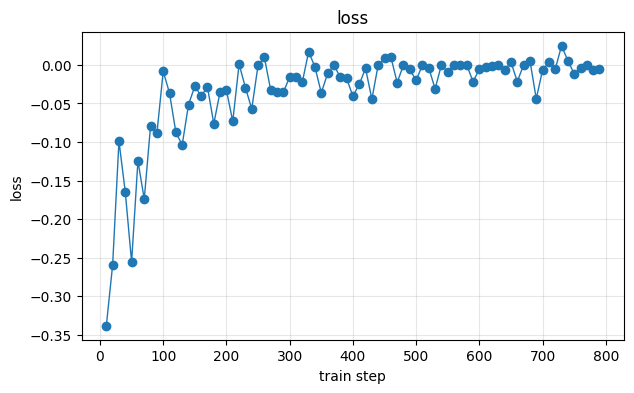

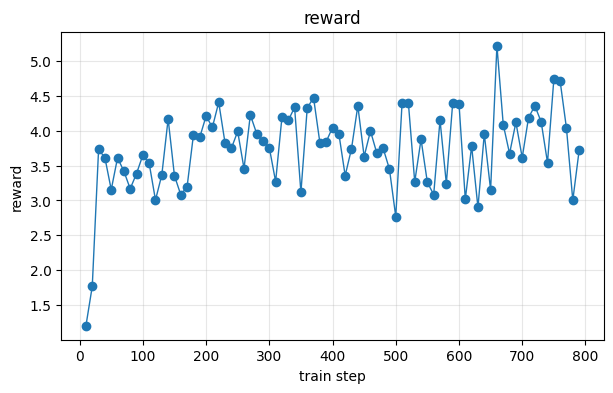

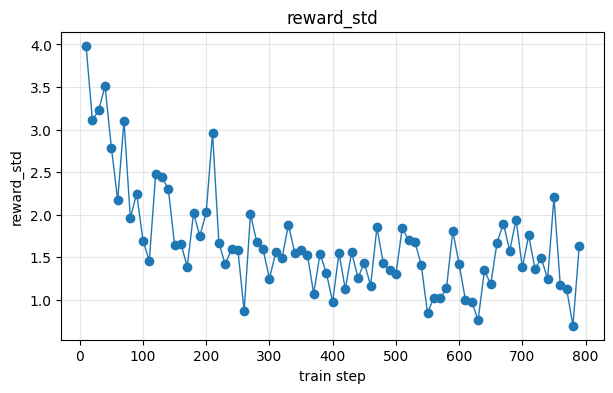

[skip] No values for kl


In [63]:

# --------- Построение графиков ---------
history = metrics_callback.history
steps = np.array(history["step"])

def plot_metric(steps, values, title):
    values = np.array(values, dtype=float)
    mask = ~np.isnan(values)
    if mask.sum() == 0:
        print(f"[skip] No values for {title}")
        return

    plt.figure(figsize=(7, 4))
    plt.plot(steps[mask], values[mask], marker="o", linewidth=1)
    plt.xlabel("train step")
    plt.ylabel(title)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_metric(steps, history["loss"], "loss")
plot_metric(steps, history["reward"], "reward")
plot_metric(steps, history["reward_std"], "reward_std")
plot_metric(steps, history["kl"], "kl")

## 17. Сравнение supervised и RL policy

После RL дообучения сравним:
- качество первого шага (`HitRate@1`);
- покрытие реального окна (`Recall@X`);
- среднюю предсказанную **суммарную** награду slate;
- склонность к повторным и популярным item'ам;
- разнообразие slate.

In [64]:
def sample_predictions(model, examples_df, n_eval=300, slate_size=3):
    rows = examples_df.head(n_eval)
    out = []
    counter = 0
    for r in tqdm(list(rows.itertuples()), total=len(rows)):
        pred_items, _ = generate_item_slate(
            model, r.prefix_items, slate_size=slate_size, top_k=20, temperature=1.0
        )
        counter += 1

        if counter < 10:
            print(r.prefix_items, pred_items)

        pred_reward = np.nan
        if len(pred_items) > 0:
            pred_reward = aggregate_slate_reward(
                reward_trainer.model.to(DEVICE),
                r.prefix_items,
                pred_items,
            )

        true_items = list(map(str, r.target_items))
        pred_set = set(map(str, pred_items))
        true_set = set(true_items)

        out.append({
            "user_id": r.user_id,
            "target_item": str(r.target_item),
            "target_items": true_items,
            "pred_item": str(pred_items[0]) if len(pred_items) > 0 else None,
            "pred_items": pred_items,
            "hit@1": int(len(pred_items) > 0 and str(pred_items[0]) == str(true_items[0])),
            "recall@x": len(pred_set & true_set) / max(len(true_set), 1),
            "pred_reward": pred_reward,
            "history_len": len(r.prefix_items),
            "is_repeat_pred": int(any(str(x) in set(map(str, r.prefix_items)) for x in pred_items)),
            "unique_slate_size": len(set(pred_items)),
        })
    return pd.DataFrame(out)


SLATE_SIZE = 5
base_pred_df = sample_predictions(trainer.model.to(DEVICE), test_examples, n_eval=500, slate_size=SLATE_SIZE)
rl_pred_df   = sample_predictions(grpo_trainer.model.to(DEVICE), test_examples, n_eval=500, slate_size=SLATE_SIZE)

  0%|          | 0/500 [00:00<?, ?it/s]

['10440'] ['9996', '2657', '3734', '4151', '15297']
['10440', '13865'] ['2657', '3734', '9728', '10440', '6809']
['10440', '13865', '9615'] ['142', '4495', '15297', '10440', '2657']
['10440', '13865', '9615', '2657'] ['8636', '10440', '9728', '9996', '13865']
['10440', '13865', '9615', '2657', '2656'] ['2657', '4151', '9996', '15297', '9728']
['10440', '13865', '9615', '2657', '2656', '10100'] ['8636', '4151', '142', '6443', '3734']
['10440', '13865', '9615', '2657', '2656', '10100', '142'] ['9728', '15297', '12192', '3734', '10440']
['10440', '13865', '9615', '2657', '2656', '10100', '142', '2452'] ['4151', '10440', '3734', '8636', '4740']
['10440', '13865', '9615', '2657', '2656', '10100', '142', '2452', '3734'] ['4151', '15297', '9996', '2657', '142']


  0%|          | 0/500 [00:00<?, ?it/s]

['10440'] ['1844', '3379', '13744', '16456', '8484']
['10440', '13865'] ['2657', '7556', '15340', '2566', '14061']
['10440', '13865', '9615'] ['2650', '14739', '4426', '2426', '2602']
['10440', '13865', '9615', '2657'] ['9550', '15340', '2936', '12110', '2602']
['10440', '13865', '9615', '2657', '2656'] ['14001', '14739', '15340', '5857', '13266']
['10440', '13865', '9615', '2657', '2656', '10100'] ['8484', '2936', '16456', '15552', '2426']
['10440', '13865', '9615', '2657', '2656', '10100', '142'] ['5592', '13266', '8484', '2936', '15340']
['10440', '13865', '9615', '2657', '2656', '10100', '142', '2452'] ['5592', '1167', '8484', '5983', '13266']
['10440', '13865', '9615', '2657', '2656', '10100', '142', '2452', '3734'] ['1381', '13266', '2426', '15552', '2420']


In [65]:
def summarize_policy_behavior(pred_df: pd.DataFrame, name: str):
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("HitRate@1              :", pred_df["hit@1"].mean())
    print("Recall@X               :", pred_df["recall@x"].mean())
    print("Mean predicted reward  :", pred_df["pred_reward"].mean())
    print("Repeat-rate            :", pred_df["is_repeat_pred"].mean())
    print("Unique first-item recs :", pred_df["pred_item"].nunique())
    print("Mean unique slate size :", pred_df["unique_slate_size"].mean())
    print()

summarize_policy_behavior(base_pred_df, "Supervised policy")
summarize_policy_behavior(rl_pred_df, "RL policy")

Supervised policy
HitRate@1              : 0.018
Recall@X               : 0.058
Mean predicted reward  : 11.105999741953802
Repeat-rate            : 0.472
Unique first-item recs : 45
Mean unique slate size : 5.0

RL policy
HitRate@1              : 0.002
Recall@X               : 0.004
Mean predicted reward  : 13.677068593166245
Repeat-rate            : 0.062
Unique first-item recs : 125
Mean unique slate size : 5.0



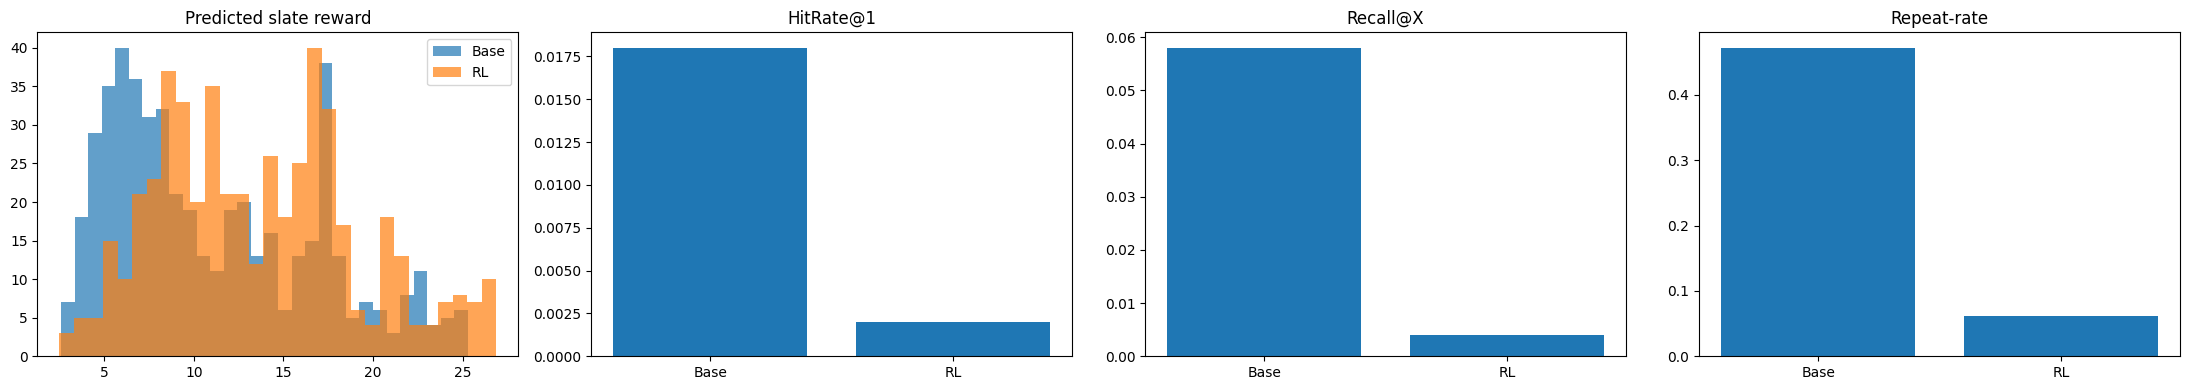

In [66]:
def plot_policy_comparison(base_pred_df: pd.DataFrame, rl_pred_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    axes[0].hist(base_pred_df["pred_reward"].dropna(), bins=30, alpha=0.7, label="Base")
    axes[0].hist(rl_pred_df["pred_reward"].dropna(), bins=30, alpha=0.7, label="RL")
    axes[0].set_title("Predicted slate reward")
    axes[0].legend()

    axes[1].bar(
        ["Base", "RL"],
        [base_pred_df["hit@1"].mean(), rl_pred_df["hit@1"].mean()]
    )
    axes[1].set_title("HitRate@1")

    axes[2].bar(
        ["Base", "RL"],
        [base_pred_df["recall@x"].mean(), rl_pred_df["recall@x"].mean()]
    )
    axes[2].set_title("Recall@X")

    axes[3].bar(
        ["Base", "RL"],
        [base_pred_df["is_repeat_pred"].mean(), rl_pred_df["is_repeat_pred"].mean()]
    )
    axes[3].set_title("Repeat-rate")

    plt.tight_layout()
    plt.show()

plot_policy_comparison(base_pred_df, rl_pred_df)

## 18. Интерпретация: что модель выучила?

Самая важная часть семинара — не просто показать RL, а понять, **куда именно сдвинулась policy**.

Теперь мы смотрим не только на первый item, но и на свойства всего slate.

In [32]:
item_popularity = train_df["item_id"].astype(str).value_counts()
popular_top_50 = set(item_popularity.head(50).index.tolist())

def add_interpretability_columns(pred_df: pd.DataFrame):
    pred_df = pred_df.copy()
    pred_df["is_popular_top50"] = pred_df["pred_item"].astype(str).isin(popular_top_50).astype(int)
    pred_df["target_is_popular_top50"] = pred_df["target_item"].astype(str).isin(popular_top_50).astype(int)
    pred_df["slate_contains_popular_top50"] = pred_df["pred_items"].apply(
        lambda xs: int(any(str(x) in popular_top_50 for x in xs)) if isinstance(xs, list) else 0
    )
    return pred_df

base_interp = add_interpretability_columns(base_pred_df)
rl_interp = add_interpretability_columns(rl_pred_df)

In [33]:
def interpret_shift(base_interp: pd.DataFrame, rl_interp: pd.DataFrame):
    print("Base popular@50 first-item rate :", base_interp["is_popular_top50"].mean())
    print("RL   popular@50 first-item rate :", rl_interp["is_popular_top50"].mean())
    print("Base slate contains popular@50  :", base_interp["slate_contains_popular_top50"].mean())
    print("RL   slate contains popular@50  :", rl_interp["slate_contains_popular_top50"].mean())
    print("Base repeat-rate                :", base_interp["is_repeat_pred"].mean())
    print("RL   repeat-rate                :", rl_interp["is_repeat_pred"].mean())
    print("Base mean reward                :", base_interp["pred_reward"].mean())
    print("RL   mean reward                :", rl_interp["pred_reward"].mean())

interpret_shift(base_interp, rl_interp)

Base popular@50 first-item rate : 0.888
RL   popular@50 first-item rate : 0.244
Base slate contains popular@50  : 1.0
RL   slate contains popular@50  : 0.492
Base repeat-rate                : 0.494
RL   repeat-rate                : 0.164
Base mean reward                : 11.069098252911306
RL   mean reward                : 13.33572112224108
